In [1]:
%load_ext autoreload
%autoreload 2

This notebook documents the processing and harmonisation of the earthquake databases used for the record selection

In [10]:
from pathlib import Path
import pandas as pd
import numpy as np
from openquake.hazardlib.imt import AvgSA, SA, PGA, RSD595, IA
import matplotlib.pyplot as plt

from pickagm import eqdbases as eqdb
from pickagm import dfops 
from phd_project.config.config import load_config 
import phd_project.scripts.WP1_ground_motion_set.manage_flatfiles as mf
cfg = load_config()

In [11]:
# set some parameters
imts_to_keep = tuple(
    [AvgSA([0,3]).name, RSD595().name, PGA().name, SA(1.00).name, IA().name])  # strings match



# ESM

In [12]:
esm_fp = cfg["raw_data"]["esm_flatfile"]
im_start_idx = 71
components = ["U", "V"]
desired_metadata = ["index", "database", "event_id", "event_time", "station_code", 
                    "location_code", "trt", "mag", "rjb", "vs30",
                    "max_usable_T", "component"]

# previously selected records that failed to download from esm database
# these need to be removed from the flatfile before selecting records
esm_download_manifest_fp = Path(cfg['raw_data']['esm_download_manifest'])

In [14]:
esm_original = mf.load_esm_flatfile(esm_fp)  # loaded with all values as strings

if esm_download_manifest_fp.exists():
    print(f"Found esm download manifest at {esm_download_manifest_fp}.\n"
          f"Records that have not been successfully downloaded from the esm "
          f"database will not be included in the selection database.")
    
    esm_download_manifest = pd.read_csv(esm_download_manifest_fp, dtype=str)
    failed_downloads = esm_download_manifest[
        esm_download_manifest["status"] != "downloaded"]

    # remove the failed downloads from the flatfile because they need to be excluded from the selection
    cols = ["event_id", "station_code"]

    # Left merge onto the failed downloads to identify which records are in both
    # dataframes and which are only in the original file. The indicator column will show this.
    merged = esm_original.merge(
        failed_downloads[cols], 
        on=cols, 
        how="left", 
        indicator=True
    )

    # True for rows in esm_original that are NOT in failed_downloads
    mask = merged["_merge"] == "left_only"
    esm_failed_downloads_removed = esm_original[mask]
    print(f"Removed {sum(~mask)} records from consideration.")

# extract the metadata etc.
metadata = eqdb.extract_metadata(esm_failed_downloads_removed, im_start_idx)
imdata = eqdb.extract_im_data(esm_failed_downloads_removed, im_start_idx)
metadata = mf.label_record_trts_esm(metadata) # add the trt type to each record
im_start_idx += 1         # one new column added


Found esm download manifest at C:\Users\clemettn\Documents\phd\data_raw\gm_records\ESM\esm_hdf5_download_manifest.csv.
Records that have not been successfully downloaded from the esm database will not be included in the selection database.
Removed 903 records from consideration.


In [15]:
# rename the im columns
imdata = eqdb.rename_sa_columns_esm(imdata)
imdata.columns = pd.MultiIndex.from_tuples(
    [(c.split("_")[0], c.split("_")[1]) for c in imdata.columns])

# keep only U-V components of the records remove the rest
imdata = imdata[components]
imdata = imdata.astype(np.float64)

In [16]:
# stack arrays and add index and component columns
dfs = [pd.concat([metadata.assign(component=c), imdata[c]], axis=1) 
        for c in components]
df = pd.concat(dfs, axis=0)         # stack dfs vertically
df = df.reset_index() 
im_start_idx += 2           # two new columns added

In [17]:
# translate column names to OpenQuake IMT strings
columns = []
for c in df.columns:
    try:
        new_col = eqdb.esm_nonSA_im_translations[c]
    except KeyError:
        new_col = c
    columns.append(new_col)
df.columns = columns

In [18]:
# make PGA absolute
df["PGA"] = np.abs(df["PGA"])

# add the AvgSA([0, 3]) and AvgSA([0, 6]) columns
metadata = eqdb.extract_metadata(df, im_start_idx)
imdata = eqdb.extract_im_data(df, im_start_idx)
AvgSA_tags = ["AvgSA([0, 3])", "AvgSA([0, 6])"]
AvgSA_periods = [np.round(np.linspace(0, 3, 10), 3), 
                 np.round(np.linspace(0, 6, 10), 3)]

imdata = mf.add_AvgSA_columns2(imdata, AvgSA_tags, AvgSA_periods)    

# scale ims to desired units
imdata = mf.scale_cols(imdata, eqdb.esm_unit_conversions)

# drop unneeded ims
imdata = imdata[[c for c in imdata.columns if c.startswith(imts_to_keep)]]

# get the sa periods
sa_periods = mf.get_SA_periods_from_headers(df)


In [19]:
# organise the metadata and multiindex
metadata.loc[:, "max_usable_T"] = 0.8 / metadata[["U_hp", "V_hp"]].apply(pd.to_numeric).min(axis=1).copy()
metadata.loc[:, "mag"] = metadata["EMEC_Mw"].combine_first(metadata["Mw"]).copy()
metadata.loc[:, "rjb"] = metadata["JB_dist"].combine_first(metadata["epi_dist"]).copy()
metadata.loc[:, "vs30"] = metadata["vs30_m_sec"].combine_first(metadata["vs30_m_sec_WA"]).copy()
metadata.loc[:, "database"] = "ESM"
metadata = metadata[desired_metadata]
metadata.columns = pd.MultiIndex.from_tuples(
    [("metadata", c) for c in metadata.columns])
imdata.columns = pd.MultiIndex.from_tuples(
    [("ims", c) for c in imdata.columns])
df = pd.concat([metadata, imdata], axis=1)
esm = df.dropna(axis=0)
esm = esm.astype({
    ("metadata", "vs30"): np.float64,
    ("metadata", "rjb"): np.float64,
    ("metadata", "mag"): np.float64
})

# remove any records with zero duration
esm = esm.loc[esm[("ims", "RSD595")] > 0, :]
# remove any records with location code not == 0
esm = esm.loc[esm[("metadata", "location_code")] == "00", :]

esm_dtypes = esm.dtypes

In [20]:
# save the final dataframe
esm.to_csv(cfg["proc_data"]["gm_databases_for_selection"] / "esm_records.csv", 
          sep=",", index=False)

# NGA-Sub

In [21]:
# load the data
ngasub_meta_fp = cfg["raw_data"]["gm_flatfiles"] / "NGASub_Metadata_SA_rotD50.csv"

ngasub_SA_H1_fp = cfg["raw_data"]["gm_flatfiles"] / "NGASub_SA_H1.csv"
ngasub_SA_H2_fp = cfg["raw_data"]["gm_flatfiles"] / "NGASub_SA_H2.csv"
ngasub_Duration_fp = cfg["raw_data"]["gm_flatfiles"] / "NGASub_duration_metrics_H1H2V.csv"

# components = ["U", "V"]
metadata_rename = {"NGAsubRSN":"index", "NGAsubEQID": "event_id", 
                   "NGAsubSSN": "station_code",
                   "Earthquake_Magnitude": "mag", 
                   "Intra_Inter_Flag": "trt",
                   "Rjb_km": "rjb", "Vs30_Selected_for_Analysis_m_s": "vs30",
                   "Longest_Usable_Period_for_PSa_Ave_Component_sec":"max_usable_T", 
                   }
trt_map = {0: "Subduction Interface",
           1: "Subduction Inslab"}

In [22]:
df_meta = pd.read_csv(ngasub_meta_fp, header=0, encoding="cp1252", 
                      dtype={"Interface_Event_FromHypocenterDepth": str,
                             "Instrument_Type": str,
                             "Geomatrix_Site_Code_1st_Letter": str})
df_meta = df_meta.iloc[:, 0:84]

In [23]:
# rename some columns and add some dummy metadata to match the columns in ESM
df_meta = df_meta.rename(columns=metadata_rename)
df_meta.loc[:, "database"] = "NGASub"
df_meta.loc[:, "event_time"] = "YYYY-MM-DD HH:MM:00"
df_meta.loc[:, "location_code"] = 0
df_meta.loc[:, "component"] = "H"
df_meta = df_meta[desired_metadata]
df_meta.columns = pd.MultiIndex.from_product([["metadata"], df_meta.columns])

In [24]:
# load the H1 spectral acceleration values
df_SA1 = pd.read_csv(ngasub_SA_H1_fp, header=0, encoding="cp1252", 
                      dtype={"Interface_Event_FromHypocenterDepth": str,
                             "Instrument_Type": str,
                             "Geomatrix_Site_Code_1st_Letter": str})
df_SA1 = df_SA1.iloc[:, 12:]
df_SA1 = df_SA1.drop(columns=["PGV_cm_sec", "PGD_cm"])

# rename the columns
new_sa_cols = ["PGA"] + [f"SA({c.split("pt")[0][1:]}.{c.split("pt")[1][:-1]})" for c in df_SA1.columns[1:]]
df_SA1.columns = new_sa_cols

# interpolate for the periods that we actually want
df_SA1 = df_SA1.replace(-999, np.nan)
interped_SA_1 = mf.interpolate_SA_values(df_SA1, sa_periods)

# calculate the average spectral acceleration
AvgSA_tags = ["AvgSA([0, 3])", "AvgSA([0, 6])"]
AvgSA_periods = [np.round(np.linspace(0, 3, 10), 3), 
                 np.round(np.linspace(0, 6, 10), 3)]

AvgSA_1 = mf.add_AvgSA_columns2(df_SA1, AvgSA_tags, AvgSA_periods)[AvgSA_tags] 


In [25]:
# load the H2 spectral acceleration values
df_SA2 = pd.read_csv(ngasub_SA_H2_fp, header=0, encoding="cp1252", 
                      dtype={"Interface_Event_FromHypocenterDepth": str,
                             "Instrument_Type": str,
                             "Geomatrix_Site_Code_1st_Letter": str})
df_SA2 = df_SA2.iloc[:, 12:]
df_SA2 = df_SA2.drop(columns=["PGV_cm_sec", "PGD_cm"])

# rename the columns
new_sa_cols = ["PGA"] + [f"SA({c.split("pt")[0][1:]}.{c.split("pt")[1][:-1]})" for c in df_SA2.columns[1:]]
df_SA2.columns = new_sa_cols

# interpolate for the periods that we actually want
df_SA2 = df_SA2.replace(-999, np.nan)
interped_SA_2 = mf.interpolate_SA_values(df_SA2, sa_periods)

# calculate the average spectral acceleration
AvgSA_2 = mf.add_AvgSA_columns2(df_SA2, AvgSA_tags, AvgSA_periods)[AvgSA_tags] 


In [26]:
# Load duration metrics
df_Dur = pd.read_csv(ngasub_Duration_fp, header=0, encoding="cp1252")
rsd595_1 = df_Dur["H1_Duration_0pt05_0pt95"]
rsd595_2 = df_Dur["H2_Duration_0pt05_0pt95"] 
ai_1 = df_Dur["H1_Arias_Intensity_m_s_tot"]  
ai_2 = df_Dur["H2_Arias_Intensity_m_s_tot"] 

In [27]:
# Stack 'em all together
H1_ims = pd.concat([rsd595_1.rename("RSD595"), ai_1.rename("IA"), AvgSA_1, df_SA1["PGA"], interped_SA_1], axis=1)
H1_ims.columns = pd.MultiIndex.from_product([["ims"], H1_ims.columns])
H2_ims = pd.concat([rsd595_2.rename("RSD595"), ai_2.rename("IA"), AvgSA_2, df_SA2["PGA"], interped_SA_2], axis=1)
H2_ims.columns = pd.MultiIndex.from_product([["ims"], H2_ims.columns])

H1_df = pd.concat([df_meta, H1_ims], axis=1)
H1_df[("metadata", "component")] = "H1"
H2_df = pd.concat([df_meta, H2_ims], axis=1)
H2_df[("metadata", "component")] = "H2"

NGAsub = pd.concat([H1_df, H2_df], axis=0)

# filter the TRT to only use Interface "0" and Inslab "1" events
mask = (NGAsub[("metadata", "trt")] == 0) | (NGAsub[("metadata", "trt")] == 1)
NGAsub = NGAsub.loc[mask, :]

# replace the trt integers with names
NGAsub[("metadata", "trt")] = NGAsub[("metadata", "trt")].replace(0, "Subduction Interface")
NGAsub[("metadata", "trt")] = NGAsub[("metadata", "trt")].replace(1, "Subduction Inslab")

# tweak the types to match esm df
NGAsub = NGAsub.astype(esm_dtypes)

# replace -999 with nan
NGAsub[("metadata", "vs30")] = NGAsub[("metadata", "vs30")].replace(-999, np.nan)
NGAsub[("metadata", "rjb")] = NGAsub[("metadata", "rjb")].replace(-999, np.nan)
NGAsub[("metadata", "max_usable_T")] = NGAsub[("metadata", "max_usable_T")].replace(-999, np.nan)
NGAsub = NGAsub.dropna(axis=0)

# remove records where the duration is 0.0s
NGAsub = NGAsub.loc[NGAsub[("ims", "RSD595")] > 0, :]

In [28]:
# check that all the columns are the same
all(NGAsub.columns.sort_values() == esm.columns.sort_values())

True

In [29]:
# save the final dataframe
NGAsub.to_csv(cfg["proc_data"]["gm_databases_for_selection"] / "NGAsub_records.csv", 
          sep=",", index=False)

In [30]:
NGAsub

metadata                                                      \
         index database event_id           event_time station_code   
0      1000001   NGASub  1000001  YYYY-MM-DD HH:MM:00      1000001   
1      1000002   NGASub  1000001  YYYY-MM-DD HH:MM:00      1000002   
2      1000003   NGASub  1000001  YYYY-MM-DD HH:MM:00      1000003   
3      1000004   NGASub  1000001  YYYY-MM-DD HH:MM:00      1000004   
4      1000005   NGASub  1000001  YYYY-MM-DD HH:MM:00      1000005   
...        ...      ...      ...                  ...          ...   
70872  7012036   NGASub  7000074  YYYY-MM-DD HH:MM:00      7000819   
70873  7012037   NGASub  7000074  YYYY-MM-DD HH:MM:00      7000828   
70874  7012038   NGASub  7000074  YYYY-MM-DD HH:MM:00      7000839   
70875  7012039   NGASub  7000074  YYYY-MM-DD HH:MM:00      7000834   
70876  7012040   NGASub  7000074  YYYY-MM-DD HH:MM:00      7000829   

                                                                          ...  \
      location_code                   trt   mag          rjb        vs30  ...   
0                 0     Subduction Inslab  7.96  1650.425991  750.000000  ...   
1                 0     Subduction Inslab  7.96   407.259911  635.000000  ...   
2                 0     Subduction Inslab  7.96  1658.439810  455.000000  ...   
3                 0     Subduction Inslab  7.96  1398.260494  750.000000  ...   
4                 0     Subduction Inslab  7.96  1155.785064  455.000000  ...   
...             ...                   ...   ...          ...         ...  ...   
70872             0  Subduction Interface  5.69   268.762257  528.340279  ...   
70873             0  Subduction Interface  5.69   123.113508  655.740832  ...   
70874             0  Subduction Interface  5.69   107.693203  655.740832  ...   
70875             0  Subduction Interface  5.69   108.333462  655.740832  ...   
70876             0  Subduction Interface  5.69   112.985184  655.740832  ...   

            ims                                                              \
        SA(3.0)   SA(3.5)   SA(4.0)   SA(4.5)   SA(5.0)   SA(6.0)   SA(7.0)   
0      0.000095  0.000086  0.000074  0.000073  0.000070  0.000066  0.000067   
1      0.001949  0.001486  0.001319  0.001068  0.000821  0.000646  0.000418   
2      0.000190  0.000152  0.000149  0.000144  0.000134  0.000134  0.000086   
3      0.000117  0.000136  0.000169  0.000127  0.000131  0.000173  0.000130   
4      0.000420  0.000543  0.000607  0.000339  0.000229  0.000198  0.000198   
...         ...       ...       ...       ...       ...       ...       ...   
70872  0.000051  0.000065  0.000049  0.000040  0.000032  0.000025  0.000023   
70873  0.000874  0.000643  0.000525  0.000364  0.000279  0.000136  0.000096   
70874  0.000635  0.000423  0.000272  0.000151  0.000131  0.000071  0.000076   
70875  0.000570  0.000387  0.000242  0.000140  0.000108  0.000072  0.000046   
70876  0.000188  0.000146  0.000121  0.000082  0.000056  0.000035  0.000035   

                                     
        SA(8.0)   SA(9.0)  SA(10.0)  
0      0.000064  0.000086  0.000094  
1      0.000407  0.000299  0.000259  
2      0.000086  0.000089  0.000080  
3      0.000057  0.000042  0.000048  
4      0.000167  0.000133  0.000123  
...         ...       ...       ...  
70872  0.000022  0.000015  0.000009  
70873  0.000072  0.000066  0.000061  
70874  0.000057  0.000042  0.000027  
70875  0.000035  0.000034  0.000032  
70876  0.000033  0.000039  0.000040  

[88154 rows x 53 columns]

# Final Database

In [31]:
final_db = pd.concat([esm, NGAsub], axis=0)

# save the final dataframe
final_db.to_csv(cfg["proc_data"]["gm_databases_for_selection"] / "ESM-NGAsub_combined.csv", 
          sep=",", index=False)

In [32]:
final_db

metadata                                                           \
         index database      event_id           event_time station_code   
0            0      ESM  AL-2014-0005  2014-01-20 14:40:48         FIER   
1            1      ESM  AL-2014-0005  2014-01-20 14:40:48          KKS   
2            2      ESM  AL-2014-0005  2014-01-20 14:40:48          SDA   
10          10      ESM  AL-2016-0003  2016-11-10 12:12:42          KBN   
11          11      ESM  AL-2016-0004  2016-10-16 02:18:44         DURR   
...        ...      ...           ...                  ...          ...   
70872  7012036   NGASub       7000074  YYYY-MM-DD HH:MM:00      7000819   
70873  7012037   NGASub       7000074  YYYY-MM-DD HH:MM:00      7000828   
70874  7012038   NGASub       7000074  YYYY-MM-DD HH:MM:00      7000839   
70875  7012039   NGASub       7000074  YYYY-MM-DD HH:MM:00      7000834   
70876  7012040   NGASub       7000074  YYYY-MM-DD HH:MM:00      7000829   

                                                                          ...  \
      location_code                   trt   mag         rjb         vs30  ...   
0                00       Shallow Default  4.07   65.300000   374.000000  ...   
1                00       Shallow Default  4.07  117.800000   745.000000  ...   
2                00       Shallow Default  4.07   83.600000  1118.000000  ...   
10               00       Shallow Default  4.40  167.200000   742.000000  ...   
11               00       Shallow Default  4.00  203.300000   202.000000  ...   
...             ...                   ...   ...         ...          ...  ...   
70872             0  Subduction Interface  5.69  268.762257   528.340279  ...   
70873             0  Subduction Interface  5.69  123.113508   655.740832  ...   
70874             0  Subduction Interface  5.69  107.693203   655.740832  ...   
70875             0  Subduction Interface  5.69  108.333462   655.740832  ...   
70876             0  Subduction Interface  5.69  112.985184   655.740832  ...   

            ims                                                                \
        SA(4.0)   SA(4.5)   SA(5.0)       SA(6.0)       SA(7.0)       SA(8.0)   
0      0.000014  0.000012  0.000007  4.560652e-06  2.990826e-06  2.332314e-06   
1      0.000004  0.000003  0.000003  1.768603e-06  1.130479e-06  7.940877e-07   
2      0.000003  0.000002  0.000001  9.194699e-07  5.310907e-07  4.994903e-07   
10     0.000011  0.000012  0.000009  7.024465e-06  4.566769e-06  3.087666e-06   
11     0.000008  0.000006  0.000004  2.323140e-06  1.792049e-06  1.353721e-06   
...         ...       ...       ...           ...           ...           ...   
70872  0.000049  0.000040  0.000032  2.518480e-05  2.307760e-05  2.153180e-05   
70873  0.000525  0.000364  0.000279  1.356100e-04  9.643870e-05  7.176450e-05   
70874  0.000272  0.000151  0.000131  7.084030e-05  7.554050e-05  5.688220e-05   
70875  0.000242  0.000140  0.000108  7.212510e-05  4.593210e-05  3.466590e-05   
70876  0.000121  0.000082  0.000056  3.523040e-05  3.476950e-05  3.280670e-05   

                                                               
            SA(9.0)      SA(10.0) AvgSA([0, 3]) AvgSA([0, 6])  
0      1.814475e-06  1.530071e-06      0.000076      0.000026  
1      6.014271e-07  4.852192e-07      0.000026      0.000009  
2      3.547401e-07  2.915392e-07      0.000018      0.000006  
10     1.922528e-06  1.466871e-06      0.000045      0.000021  
11     1.021407e-06  8.593272e-07      0.000073      0.000020  
...             ...           ...           ...           ...  
70872  1.450840e-05  9.193440e-06      0.000147      0.000078  
70873  6.587410e-05  6.076880e-05      0.004157      0.001236  
70874  4.190750e-05  2.718340e-05      0.001650      0.000541  
70875  3.401800e-05  3.208230e-05      0.001245      0.000447  
70876  3.876600e-05  4.003190e-05      0.000355      0.000163  

[128816 rows x 53 columns]

Text(0, 0.5, '# Records')

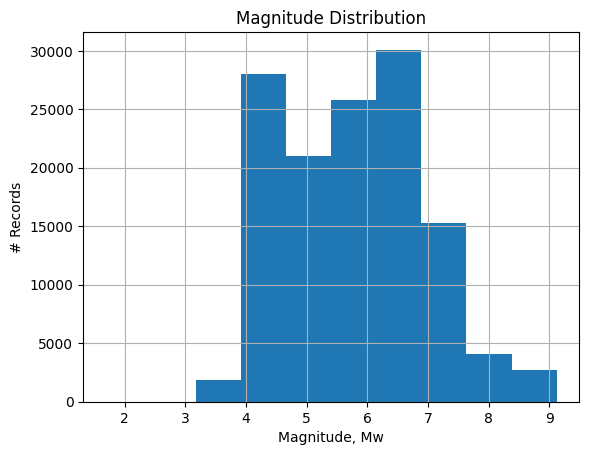

In [33]:
ax = final_db[("metadata", "mag")].hist()
ax.set_title("Magnitude Distribution")
ax.set_xlabel("Magnitude, Mw")
ax.set_ylabel("# Records")

Text(0, 0.5, 'Magnitude [Mw]')

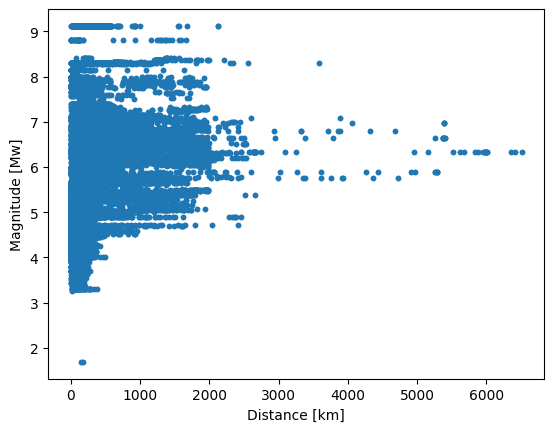

In [34]:
fig, ax = plt.subplots()
ax.scatter(final_db[("metadata", "rjb")], final_db[("metadata", "mag")], marker=".")
ax.set_xlabel("Distance [km]")
ax.set_ylabel("Magnitude [Mw]")
